In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "1"

In [2]:
df = pd.read_csv(r"C:\Users\prati\Downloads\wine.csv")

In [3]:
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [4]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [5]:
df.shape

(178, 14)

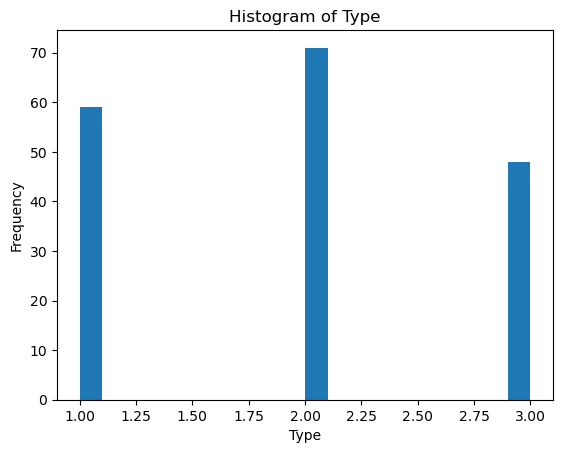

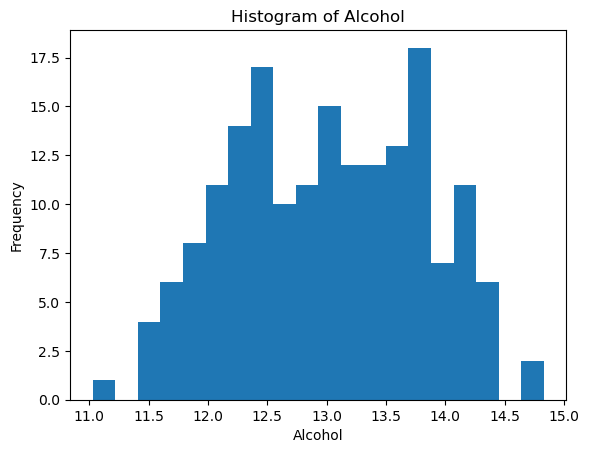

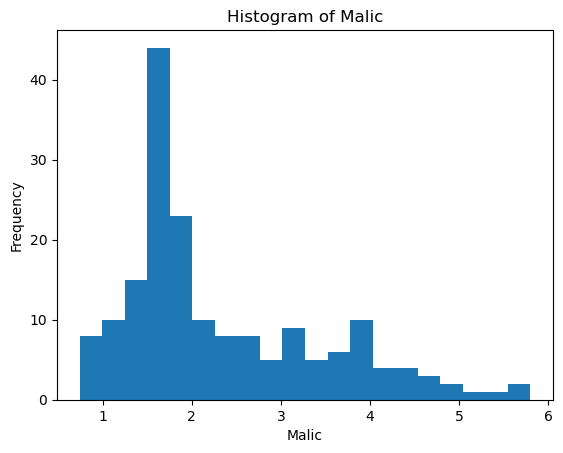

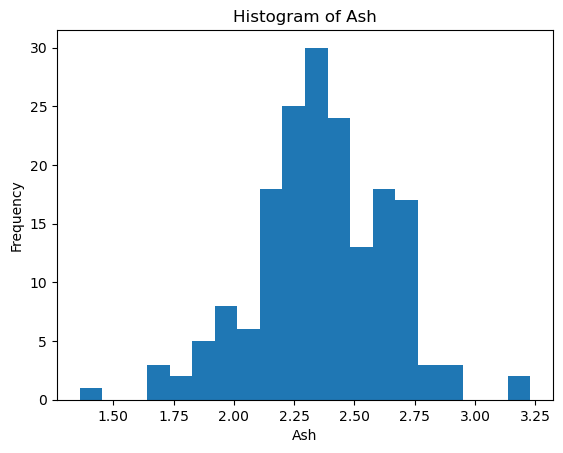

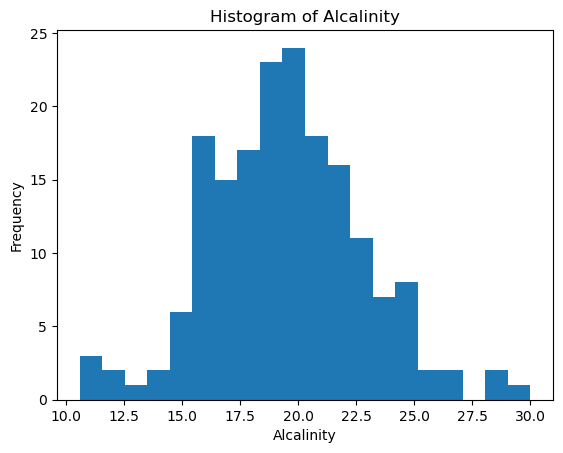

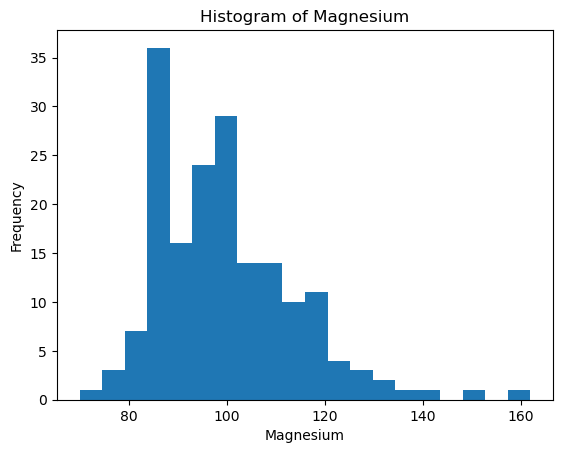

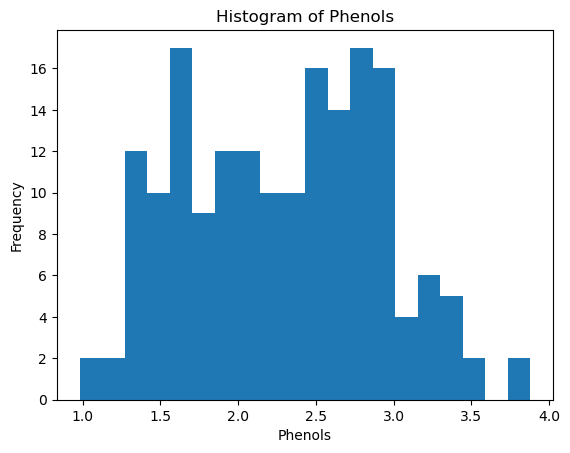

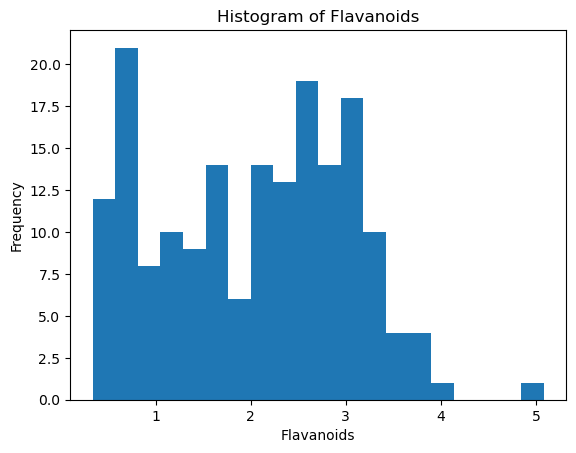

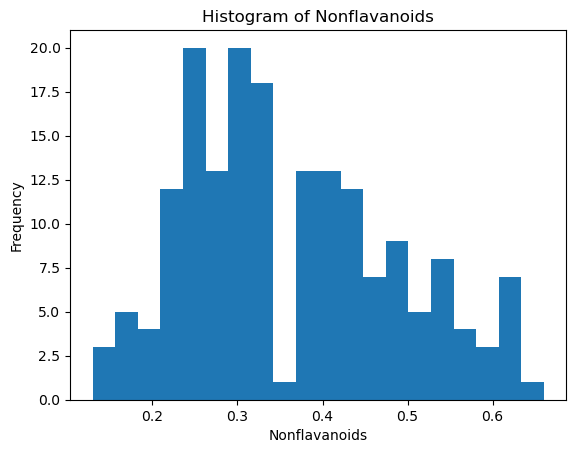

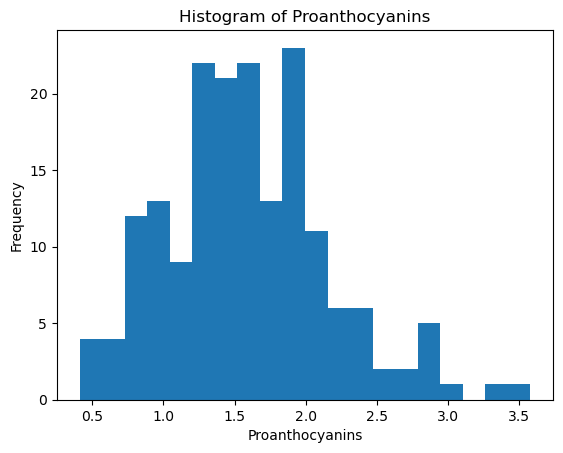

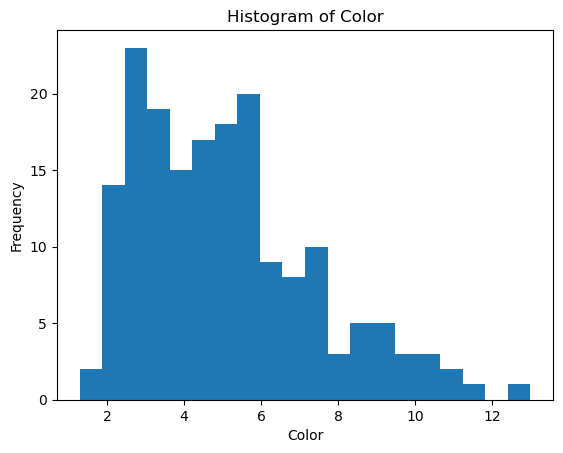

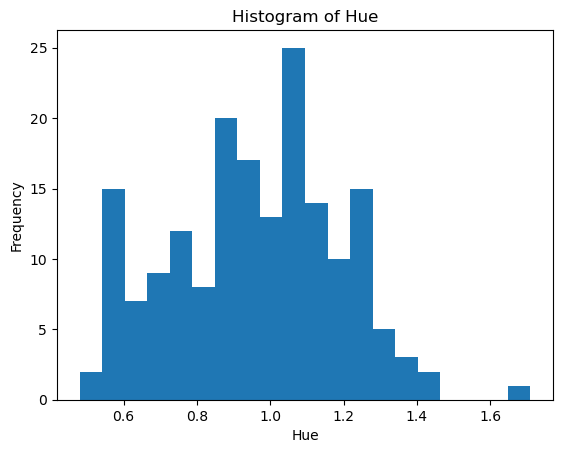

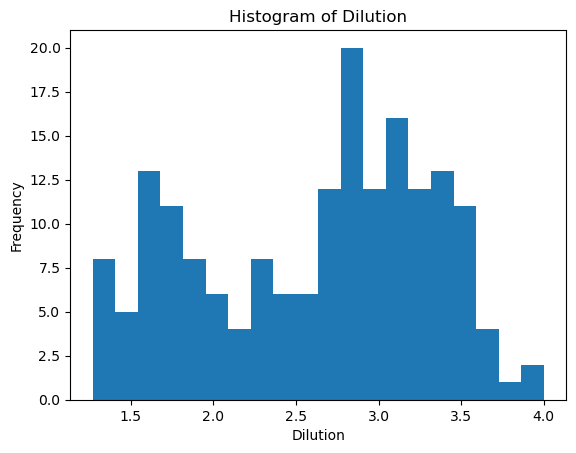

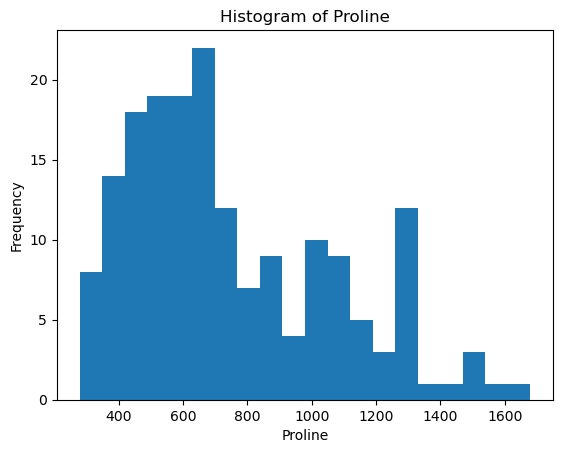

In [6]:
# Task 1.2: Examine distribution of features using histograms
for column in df.columns:
    plt.figure()
    plt.hist(df[column], bins=20)
    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

In [7]:
# Task 1.3: Investigate correlations between features
corr_matrix = df.corr()
print("\nCorrelation matrix:\n", corr_matrix)


Correlation matrix:
                      Type   Alcohol     Malic       Ash  Alcalinity  \
Type             1.000000 -0.328222  0.437776 -0.049643    0.517859   
Alcohol         -0.328222  1.000000  0.094397  0.211545   -0.310235   
Malic            0.437776  0.094397  1.000000  0.164045    0.288500   
Ash             -0.049643  0.211545  0.164045  1.000000    0.443367   
Alcalinity       0.517859 -0.310235  0.288500  0.443367    1.000000   
Magnesium       -0.209179  0.270798 -0.054575  0.286587   -0.083333   
Phenols         -0.719163  0.289101 -0.335167  0.128980   -0.321113   
Flavanoids      -0.847498  0.236815 -0.411007  0.115077   -0.351370   
Nonflavanoids    0.489109 -0.155929  0.292977  0.186230    0.361922   
Proanthocyanins -0.499130  0.136698 -0.220746  0.009652   -0.197327   
Color            0.265668  0.546364  0.248985  0.258887    0.018732   
Hue             -0.617369 -0.071747 -0.561296 -0.074667   -0.273955   
Dilution        -0.788230  0.072343 -0.368710  0.003911

In [8]:
# Task 2.1: Standardize features (mean = 0, std = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [9]:
# Apply PCA to scaled data
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

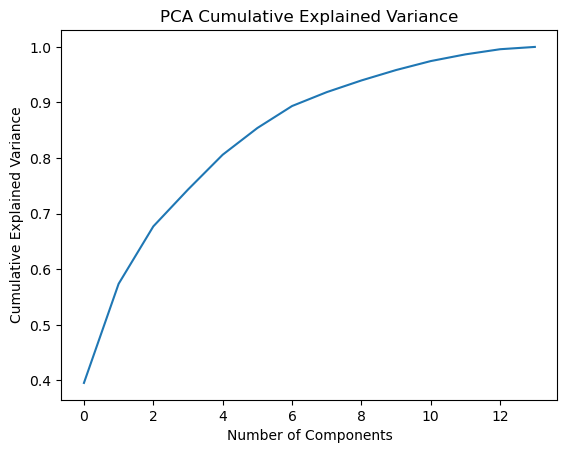

In [10]:
# Task 2.2: Determine optimal number of components (scree plot)
plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.show()

In [11]:
# Select number of components explaining ~95% variance
n_components = np.argmax(
    np.cumsum(pca.explained_variance_ratio_) >= 0.95
) + 1
print("Optimal number of PCA components:", n_components)

Optimal number of PCA components: 10


In [12]:
# Task 2.3: Transform dataset into selected principal components
pca = PCA(n_components=n_components)
X_pca_reduced = pca.fit_transform(X_scaled)

In [13]:
# Task 3.1: Apply K-means clustering to original data
kmeans_orig = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_orig = kmeans_orig.fit_predict(X_scaled)

In [14]:
# Task 3.3: Evaluate clustering performance
silhouette_orig = silhouette_score(X_scaled, labels_orig)
db_orig = davies_bouldin_score(X_scaled, labels_orig)


In [15]:
print("\nOriginal Data Clustering Metrics:")
print("Silhouette Score:", silhouette_orig)
print("Davies-Bouldin Index:", db_orig)


Original Data Clustering Metrics:
Silhouette Score: 0.30773604383565206
Davies-Bouldin Index: 1.3163957434114109


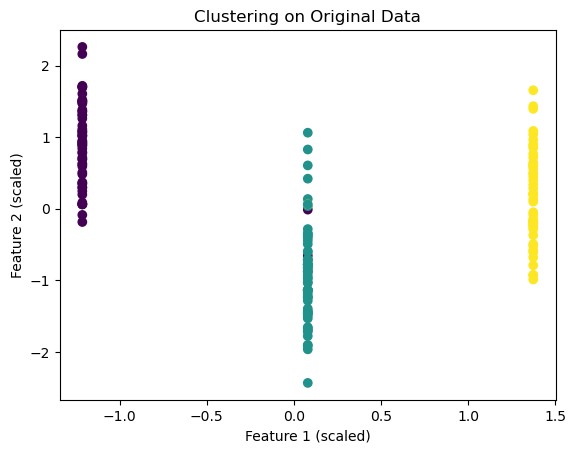

In [16]:
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_orig)
plt.title("Clustering on Original Data")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.show()

In [17]:
# Task 4.1: Apply K-means clustering to PCA-transformed data
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_pca = kmeans_pca.fit_predict(X_pca_reduced)

In [18]:
# Task 4.3: Evaluate PCA clustering performance
silhouette_pca = silhouette_score(X_pca_reduced, labels_pca)
db_pca = davies_bouldin_score(X_pca_reduced, labels_pca)

In [19]:
print("\nPCA Data Clustering Metrics:")
print("Silhouette Score:", silhouette_pca)
print("Davies-Bouldin Index:", db_pca)


PCA Data Clustering Metrics:
Silhouette Score: 0.3240658205331188
Davies-Bouldin Index: 1.2584890242254978


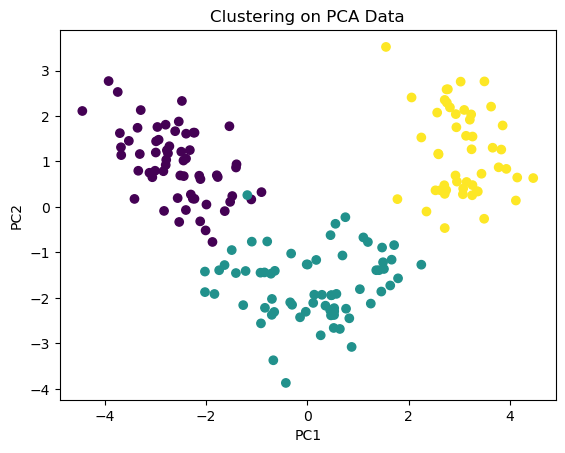

In [20]:
# Task 4.2: Visualize clustering results in PCA space
plt.figure()
plt.scatter(X_pca_reduced[:, 0], X_pca_reduced[:, 1], c=labels_pca)
plt.title("Clustering on PCA Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [21]:
print("\nComparison of Clustering Results:")
print(f"Original Silhouette Score: {silhouette_orig}")
print(f"PCA Silhouette Score: {silhouette_pca}")
print(f"Original Davies-Bouldin Index: {db_orig}")
print(f"PCA Davies-Bouldin Index: {db_pca}")


Comparison of Clustering Results:
Original Silhouette Score: 0.30773604383565206
PCA Silhouette Score: 0.3240658205331188
Original Davies-Bouldin Index: 1.3163957434114109
PCA Davies-Bouldin Index: 1.2584890242254978


In [22]:
print("""The clustering performance was evaluated using two metrics: Silhouette Score and Davies–Bouldin Index.
Original Silhouette Score: 0.3077
PCA Silhouette Score: 0.3241
Original Davies–Bouldin Index: 1.3164
PCA Davies–Bouldin Index: 1.2585
The silhouette score measures how well-separated the clusters are, with higher values indicating better-defined clusters. The PCA-transformed dataset achieved a higher silhouette score than the original dataset, suggesting improved cluster separation after dimensionality reduction.
The Davies–Bouldin index measures cluster compactness and separation, where lower values indicate better clustering performance. The PCA dataset produced a lower Davies–Bouldin index compared to the original dataset, indicating tighter and more distinct clusters.
Overall, clustering on the PCA-transformed data performed slightly better than clustering on the original dataset. This improvement suggests that PCA helped reduce noise and redundancy in the data, making the cluster structure clearer and more effective for K-means clustering.""")

The clustering performance was evaluated using two metrics: Silhouette Score and Davies–Bouldin Index.
Original Silhouette Score: 0.3077
PCA Silhouette Score: 0.3241
Original Davies–Bouldin Index: 1.3164
PCA Davies–Bouldin Index: 1.2585
The silhouette score measures how well-separated the clusters are, with higher values indicating better-defined clusters. The PCA-transformed dataset achieved a higher silhouette score than the original dataset, suggesting improved cluster separation after dimensionality reduction.
The Davies–Bouldin index measures cluster compactness and separation, where lower values indicate better clustering performance. The PCA dataset produced a lower Davies–Bouldin index compared to the original dataset, indicating tighter and more distinct clusters.
Overall, clustering on the PCA-transformed data performed slightly better than clustering on the original dataset. This improvement suggests that PCA helped reduce noise and redundancy in the data, making the cluster

In [23]:
print("""1. Summary of Key Findings and Insights
The exploratory analysis of the wine dataset revealed strong relationships among several features, with many variables showing significant correlations. This indicated redundancy in the dataset and justified the use of dimensionality reduction. Principal Component Analysis (PCA) reduced the dataset from 14 features to 10 principal components while preserving approximately 95% of the original variance.
When K-means clustering was applied to both the original and PCA-transformed datasets, the PCA-based clustering achieved slightly better performance. The silhouette score increased and the Davies–Bouldin index decreased, indicating improved cluster separation and compactness. However, the improvement was modest, suggesting that the original dataset already contained meaningful cluster structure. PCA mainly helped by reducing noise and simplifying the feature space.
Overall, the analysis demonstrated that PCA can enhance clustering effectiveness by removing redundant information and improving data structure without significant loss of information.

2. Practical Implications of Using PCA and Clustering
In practical data analysis, PCA and clustering are valuable tools for exploring and understanding complex datasets.
PCA is useful for reducing dimensionality in datasets with many correlated features. It helps remove noise, simplifies data structure, improves visualization, and reduces computational cost. This is particularly important when working with high-dimensional datasets where traditional analysis may be inefficient or difficult to interpret.
Clustering is widely used to discover hidden patterns and group similar observations without prior labels. It is applied in areas such as customer segmentation, image recognition, biological classification, and anomaly detection. When PCA is combined with clustering, it often improves clustering performance by making patterns in the data more distinguishable.
Together, these techniques support better decision-making by revealing meaningful structure in large and complex datasets.

3. Recommendations for When to Use Each Technique
Based on the analysis conducted:
PCA should be used when the dataset is high-dimensional, contains correlated features, or includes noise that may interfere with analysis. It is also recommended when visualization and computational efficiency are important.
Clustering should be applied directly to the original dataset when the number of features is small and interpretability of the original variables is essential. In such cases, dimensionality reduction may not be necessary.
Using PCA followed by clustering is recommended for high-dimensional or noisy datasets where improved cluster separation and faster computation are desired. This combined approach is particularly effective when redundancy exists among features.
In general, PCA is best used as a preprocessing step for clustering when dimensionality and correlation present challenges in the original dataset.""")

1. Summary of Key Findings and Insights
The exploratory analysis of the wine dataset revealed strong relationships among several features, with many variables showing significant correlations. This indicated redundancy in the dataset and justified the use of dimensionality reduction. Principal Component Analysis (PCA) reduced the dataset from 14 features to 10 principal components while preserving approximately 95% of the original variance.
When K-means clustering was applied to both the original and PCA-transformed datasets, the PCA-based clustering achieved slightly better performance. The silhouette score increased and the Davies–Bouldin index decreased, indicating improved cluster separation and compactness. However, the improvement was modest, suggesting that the original dataset already contained meaningful cluster structure. PCA mainly helped by reducing noise and simplifying the feature space.
Overall, the analysis demonstrated that PCA can enhance clustering effectiveness by r